#  RoBERTa Emotion Classification
**Model:** `cardiffnlp/twitter-roberta-base-emotion`  
**Task:** 6-class tweet emotion detection  
**Dataset:** Kaggle Emotion Dataset  
---
### Pipeline Overview
```
Raw CSV → Language Filter → Augment → Clean → Tokenize → Fine-tune RoBERTa → Evaluate
```

##  1. Setup & Imports

In [ ]:
!pip install -q langdetect transformers[torch] datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 29.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os, re, random, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_scheduler
)
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from nltk.corpus import wordnet
from langdetect import detect
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
# ── Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

 Device: cuda


##  2. Load Dataset

In [ ]:
# Uncomment to upload in Colab:
# from google.colab import files
# files.upload()
df = pd.read_csv('emotion_dataset_raw.csv')
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()

Shape   : (34792, 2)
Columns : ['Emotion', 'Text']


,Emotion,Text
0,neutral,Why ?
1,joy,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


##  3. Exploratory Data Analysis

In [ ]:
print(f"Null values:\n{df.isnull().sum()}")
print(f"\nLabel distribution:\n{df['Emotion'].value_counts()}")

Null values:
Emotion    0
Text       0
dtype: int64
Label distribution:
Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
neutral      2254
disgust       856
shame         146
Name: count, dtype: int64


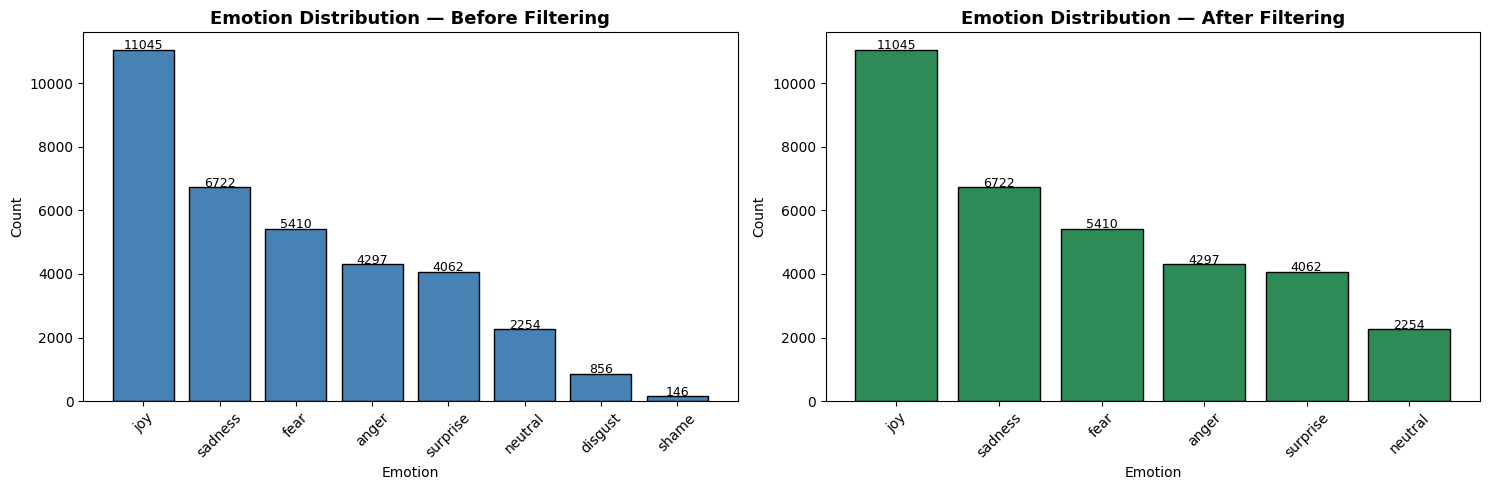

Remaining classes: ['neutral', 'joy', 'sadness', 'fear', 'surprise', 'anger']


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Before filtering
counts_before = df['Emotion'].value_counts()
axes[0].bar(counts_before.index, counts_before.values, color='steelblue', edgecolor='black')
axes[0].set_title('Emotion Distribution — Before Filtering', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)
# Remove low-frequency / irrelevant classes
REMOVE_CLASSES = ['shame', 'disgust']
df = df[~df['Emotion'].isin(REMOVE_CLASSES)].reset_index(drop=True)
counts_after = df['Emotion'].value_counts()
axes[1].bar(counts_after.index, counts_after.values, color='seagreen', edgecolor='black')
axes[1].set_title('Emotion Distribution — After Filtering', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nRemaining classes: {df['Emotion'].unique().tolist()}")

##  4. Language Filtering (English Only)

In [ ]:
def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except:
        return False
df['is_english'] = df['Text'].apply(is_english)
non_english_count = (~df['is_english']).sum()
print(f"Non-English tweets found : {non_english_count}")
df = df[df['is_english']].drop(columns=['is_english']).reset_index(drop=True)
print(f"After filtering          : {len(df)} samples")
print(f"\nLabel distribution:\n{df['Emotion'].value_counts()}")

Non-English tweets found : 2902
After filtering          : 30888 samples
Label distribution:
Emotion
joy         10604
sadness      6406
fear         5107
anger        4162
surprise     3251
neutral      1358
Name: count, dtype: int64


##  5. Data Augmentation
We balance all emotion classes to **5,000 samples** each using two NLP augmentation strategies:
- **Synonym Replacement** — swap random words with WordNet synonyms
- **Random Deletion** — randomly drop words with probability `p=0.15`

In [ ]:
TARGET = 5000
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace('_', ' ')
            if candidate.lower() != word.lower():
                synonyms.add(candidate)
    return list(synonyms)
def synonym_replacement(text, n=2):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([w for w in words if get_synonyms(w)]))
    random.shuffle(random_word_list)
    for word in random_word_list[:n]:
        synonyms = get_synonyms(word)
        if synonyms:
            new_words = [random.choice(synonyms) if w == word else w for w in new_words]
    return ' '.join(new_words)
def random_deletion(text, p=0.15):
    words = text.split()
    if len(words) == 1:
        return text
    return ' '.join([w for w in words if random.random() > p])
def augment(text):
    return synonym_replacement(text) if random.random() < 0.5 else random_deletion(text)
augmented_rows = []
for emotion in df['Emotion'].unique():
    subset = df[df['Emotion'] == emotion]
    current = len(subset)
    if current < TARGET:
        needed = TARGET - current
        samples = subset.sample(n=needed, replace=True, random_state=SEED).copy()
        samples['Text'] = samples['Text'].apply(augment)
        augmented_rows.append(samples)
        print(f"  {emotion:<12} {current:>5} → {current + needed}")
    else:
        print(f"  {emotion:<12} {current:>5}  (no augmentation needed)")
df_aug = pd.concat([df] + augmented_rows, ignore_index=True)
df_aug = df_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"\nFinal distribution:\n{df_aug['Emotion'].value_counts()}")
print(f"Total samples: {len(df_aug)}")

  joy          10604  (no augmentation needed)
  sadness       6406  (no augmentation needed)
  fear          5107  (no augmentation needed)
  anger         4162 → 5000
  surprise      3251 → 5000
  neutral       1358 → 5000
Final distribution:
Emotion
joy         10604
sadness      6406
fear         5107
surprise     5000
neutral      5000
anger        5000
Name: count, dtype: int64
Total samples: 37117


##  6. Text Cleaning

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'@\w+', '', text)           # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text
df_aug['clean_text'] = df_aug['Text'].apply(clean_text)
before = len(df_aug)
df_aug = df_aug[df_aug['clean_text'].str.strip() != ''].reset_index(drop=True)
df_aug = df_aug[df_aug['clean_text'].str.split().apply(len) > 1].reset_index(drop=True)
print(f"Removed {before - len(df_aug)} degenerate rows.")
print(f"Clean dataset size: {len(df_aug)}")
df_aug[['Text', 'clean_text', 'Emotion']].head()

Removed 90 degenerate rows.
Clean dataset size: 37027


,Text,clean_text,Emotion
0,"Law &amp; Order SVU, missing child case, voice...","Law &amp; Order SVU, missing child case, voice...",surprise
1,when my little brothers friends ovoo him and I...,when my little brothers friends ovoo him and I...,surprise
2,Goodnight ♥ I'm going to curl up with my book ...,Goodnight ♥ I'm going to curl up with my book ...,joy
3,"Do you take whatever particular hobbies , Tom ?","Do you take whatever particular hobbies , Tom ?",neutral
4,Ok - 2 bits of straightforward copy editing le...,Ok - 2 bits of straightforward copy editing le...,joy


## ️ 7. Label Encoding & Train / Val / Test Split

In [ ]:
le = LabelEncoder()
df_aug['label'] = le.fit_transform(df_aug['Emotion'])
NUM_CLASSES = len(le.classes_)
print("Label mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx} → {cls}")

Label mapping:
  0 → anger
  1 → fear
  2 → joy
  3 → neutral
  4 → sadness
  5 → surprise


In [ ]:
# 70 / 15 / 15 stratified split
X = df_aug['clean_text'].values
y = df_aug['label'].values
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
print(f"Train : {len(X_train):>6} samples")
print(f"Val   : {len(X_val):>6} samples")
print(f"Test  : {len(X_test):>6} samples")

Train :  25918 samples
Val   :   5554 samples
Test  :   5555 samples


##  8. Tokenization

In [ ]:
MODEL_NAME = 'cardiffnlp/twitter-roberta-base-emotion'
MAX_LEN    = 128
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def tokenize(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)
print(f"Token tensor shape : {train_enc['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Token tensor shape : torch.Size([25918, 128])


## ️ 9. Dataset & DataLoaders

In [ ]:
BATCH_SIZE = 32
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
train_dataset = EmotionDataset(train_enc, y_train)
val_dataset   = EmotionDataset(val_enc,   y_val)
test_dataset  = EmotionDataset(test_enc,  y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 810
Val batches   : 174
Test batches  : 174


##  10. Model — Twitter-RoBERTa
```
Input IDs + Attention Mask
         ↓
RoBERTa Transformer  (12 layers, 768 hidden dims)
         ↓
[CLS] token representation
         ↓
Dropout(0.1)
         ↓
Dense(768 → 6) + Softmax
```

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model.to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
backbone_params  = sum(p.numel() for p in model.roberta.parameters())
print(f"Backbone params  : {backbone_params:>12,}")
print(f"Trainable params : {trainable_params:>12,}")
print(f"Total params     : {total_params:>12,}")

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-emotion
Key                             | Status     |                                                                                     
++
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([4]) vs model:torch.Size([6])          
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([4, 768]) vs model:torch.Size([6, 768])
Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Backbone params  :  124,055,040
Trainable params :  124,650,246
Total params     :  124,650,246


## ️ 11. Training Configuration
| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning rate | `2e-5` | Standard sweet spot for RoBERTa fine-tuning |
| Weight decay | `0.01` | L2 regularization against overfitting |
| Scheduler | Linear warmup → decay | Stabilizes early training |
| Warmup ratio | `10%` | Prevents large early gradient steps |
| Grad clipping | `1.0` | Prevents exploding gradients |
| Early stopping | patience=3 | Avoids overfitting past peak val accuracy |

In [ ]:
EPOCHS   = 20
LR       = 2e-5
PATIENCE = 3
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print(f"LR           : {LR}")
print(f"Early stop   : patience={PATIENCE}")

Total steps  : 16200
Warmup steps : 1620
LR           : 2e-05
Early stop   : patience=3


##  12. Training Loop

In [ ]:
def evaluate(model, loader):
    """Returns (accuracy, predictions, true_labels) over a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            all_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds), all_preds, all_labels
history        = {'train_loss': [], 'val_acc': []}
best_val_acc   = 0.0
patience_count = 0
CKPT_PATH      = 'best_roberta.pt'
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if (step + 1) % 100 == 0:
            avg = total_loss / (step + 1)
            print(f"  Step {step+1:>4}/{len(train_loader)} | Loss: {avg:.4f}")
    avg_loss = total_loss / len(train_loader)
    val_acc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
        flag = '   best model saved'
    else:
        patience_count += 1
        flag = f'  (patience {patience_count}/{PATIENCE})'
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}{flag}")
    print(f"{'='*60}\n")
    if patience_count >= PATIENCE:
        print(f"️  Early stopping triggered at epoch {epoch+1}.")
        break
print(f"\n Best Validation Accuracy: {best_val_acc:.4f}")

  Step  100/810 | Loss: 1.7452
  Step  200/810 | Loss: 1.6567
  Step  300/810 | Loss: 1.5634
  Step  400/810 | Loss: 1.4704
  Step  500/810 | Loss: 1.3950
  Step  600/810 | Loss: 1.3249
  Step  700/810 | Loss: 1.2654
  Step  800/810 | Loss: 1.2171
Epoch 1/20 | Loss: 1.2122 | Val Acc: 0.7123   best model saved
  Step  100/810 | Loss: 0.7738
  Step  200/810 | Loss: 0.7651
  Step  300/810 | Loss: 0.7581
  Step  400/810 | Loss: 0.7524
  Step  500/810 | Loss: 0.7430
  Step  600/810 | Loss: 0.7356
  Step  700/810 | Loss: 0.7350
  Step  800/810 | Loss: 0.7341
Epoch 2/20 | Loss: 0.7335 | Val Acc: 0.7568   best model saved
  Step  100/810 | Loss: 0.5187
  Step  200/810 | Loss: 0.5378
  Step  300/810 | Loss: 0.5414
  Step  400/810 | Loss: 0.5382
  Step  500/810 | Loss: 0.5348
  Step  600/810 | Loss: 0.5319
  Step  700/810 | Loss: 0.5351
  Step  800/810 | Loss: 0.5319
Epoch 3/20 | Loss: 0.5316 | Val Acc: 0.7865   best model saved
  Step  100/810 | Loss: 0.3410
  Step  200/810 | Loss: 0.3445
  Ste

##  13. Training Curves

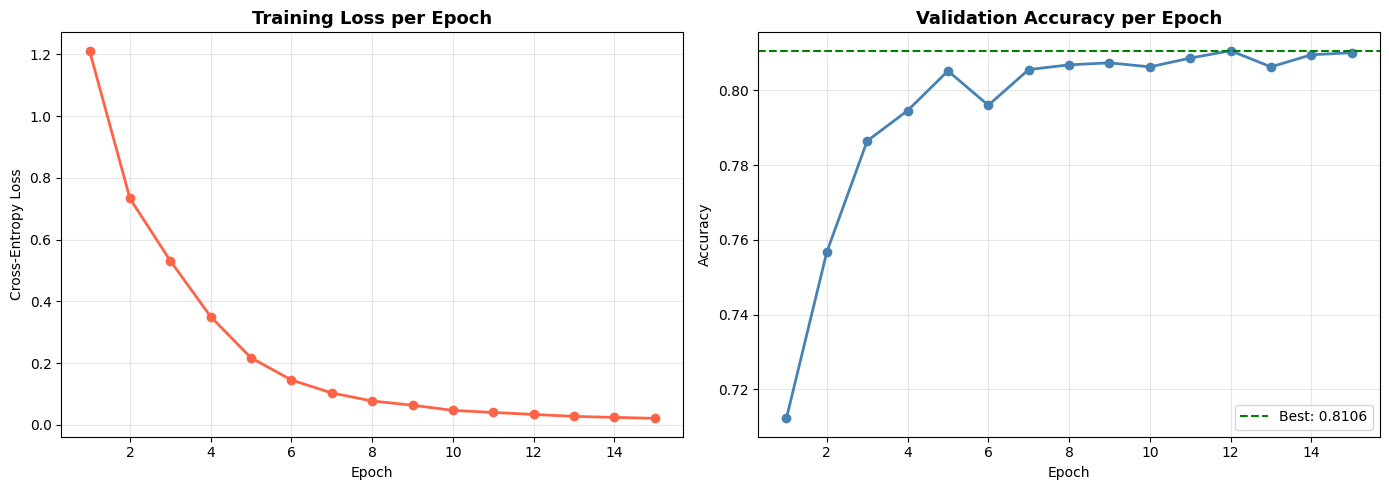

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_ran, history['train_loss'], marker='o', color='tomato', linewidth=2)
axes[0].set_title('Training Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs_ran, history['val_acc'], marker='o', color='steelblue', linewidth=2)
axes[1].axhline(best_val_acc, color='green', linestyle='--', linewidth=1.5,
                label=f'Best: {best_val_acc:.4f}')
axes[1].set_title('Validation Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

##  14. Final Evaluation on Test Set

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.to(device)
test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f" Test Accuracy : {test_acc:.4f}")
print(f"   Best Val Acc  : {best_val_acc:.4f}")

 Test Accuracy : 0.8090
   Best Val Acc  : 0.8106


In [ ]:
print("Classification Report:\n")
print(classification_report(
    test_labels, test_preds,
    target_names=le.classes_
))

Classification Report:
              precision    recall  f1-score   support
       anger       0.83      0.76      0.79       750
        fear       0.84      0.80      0.82       766
         joy       0.79      0.85      0.82      1591
     neutral       0.94      0.93      0.93       737
     sadness       0.72      0.75      0.73       961
    surprise       0.82      0.74      0.78       750
    accuracy                           0.81      5555
   macro avg       0.82      0.80      0.81      5555
weighted avg       0.81      0.81      0.81      5555


##  15. Confusion Matrix

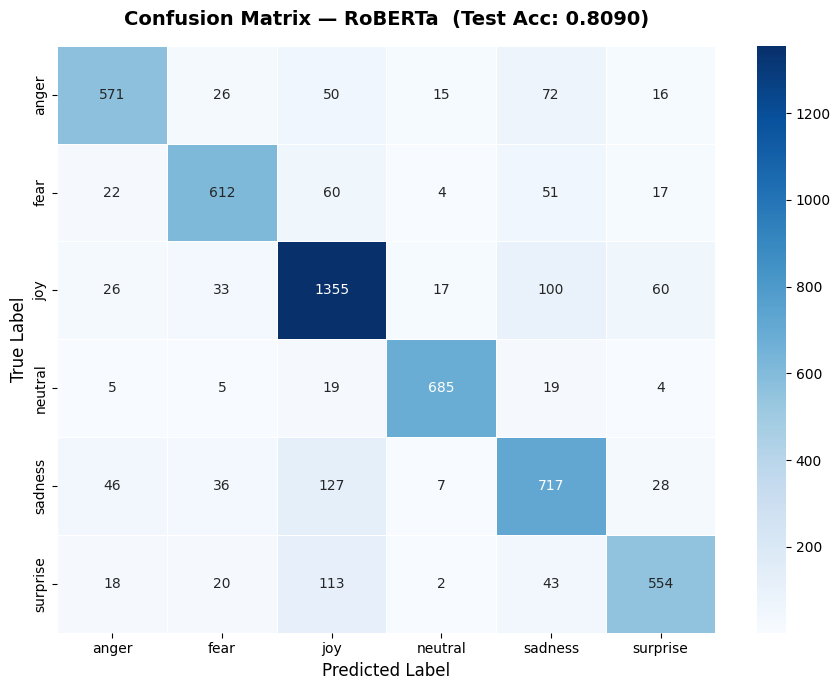

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax, linewidths=0.5
)
ax.set_title(
    f'Confusion Matrix — RoBERTa  (Test Acc: {test_acc:.4f})',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

##  16. Save Results Summary

In [ ]:
summary = {
    'model'         : MODEL_NAME,
    'num_classes'   : NUM_CLASSES,
    'classes'       : le.classes_.tolist(),
    'best_val_acc'  : round(best_val_acc, 4),
    'test_acc'      : round(test_acc, 4),
    'epochs_trained': len(history['train_loss']),
    'train_samples' : len(X_train),
    'val_samples'   : len(X_val),
    'test_samples'  : len(X_test),
}
with open('roberta_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Results saved to roberta_results.json")
print(json.dumps(summary, indent=2))

Results saved to roberta_results.json
{
  "model": "cardiffnlp/twitter-roberta-base-emotion",
  "num_classes": 6,
  "classes": [
    "anger",
    "fear",
    "joy",
    "neutral",
    "sadness",
    "surprise"
  ],
  "best_val_acc": 0.8106,
  "test_acc": 0.809,
  "epochs_trained": 15,
  "train_samples": 25918,
  "val_samples": 5554,
  "test_samples": 5555
}
